# 🎵 Music Genre Classification

This notebook presents a machine learning pipeline for classifying music genres based on GTZAN dataset.

Three models are presented:
1. Support Vector Machines (SVM) on MFCC audio features. The model used is RBF Binary Kernel SVM with both multiclass classification strategies One-vs-Rest and One-vs-One.
2. Multi-Layer Perceptron model on MFCC audio features.
3. Convolutional Neural Network on spectograms.


### Import libraries, define config, and set random seeds for reproducibility

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import random
import sys
import os
import json

import torch
import torch.nn as nn
import torch.optim as optim

import courselib.utils.loaders as loaders
from courselib.utils.splits import train_test_split
from courselib.utils.splits import train_test_split_images
from sklearn.preprocessing import StandardScaler
from courselib.models.multiclass_svm import KernelMulticlassOvR
from courselib.models.multiclass_svm import KernelMulticlassOvO
from courselib.utils.metrics import confusion_matrix
from courselib.utils.preprocessing import labels_to_numbers
from courselib.utils.preprocessing import labels_encoding
from courselib.utils.preprocessing import one_hot_encoding
from courselib.models.nn import MLP
from courselib.optimizers import AdamOptimizer
from courselib.utils.metrics import accuracy
from courselib.utils.metrics import cross_entropy
from courselib.utils.metrics import plot_learning_curves
from courselib.models.cnn import SimpleCNN, load_SimpleCNN_model


# Add the repo root (two levels up from this notebook) to sys.path
sys.path.insert(0, os.path.abspath("../../"))

config = {
    "C": 1.0,
    "kernel": "rbf",
    "random_seed": 42,
    "training_data_fraction": 0.8,
    "layer_widths": [40, 128, 64, 10],
    "optimizer_learning_rate": 0.001,
    "activation": "ReLU",
    "output_activation": "Softmax",
    "loss": "CE",
    "epochs": 200,
    "batch_size": 128,
}

config_cnn = {
    "img_size": 128,
    "batch_size": 32,
    "data_path": "./data/spectrograms",
    "training_data_fraction": 0.8,
    "epochs": 25,
    "normalize_mean": [0.5, 0.5, 0.5],
    "normalize_std": [0.5, 0.5, 0.5],
    "learning_rate": 0.001,
    "dropout": 0.0,
    "num_classes": 10,
    "activation": "ReLU"
}

np.random.seed(config["random_seed"])
random.seed(config["random_seed"])
torch.manual_seed(config["random_seed"])

### Loading
 
The GTZAN dataset has data in 2 formats:
1. 30s fragments of each song
2. Each fragment from 1. is split into 10 segments with 3s length

We will work with the 30s file.

In [2]:
df = loaders.load_music_30_sec()
#df = loaders.load_music_3_sec()

class_names = sorted(df["label"].unique().tolist())

Loading from `data/features_30_sec.csv`...


### Train-Test Split

We will train the models on all MFCC features and do the train-test split proportion 80/20.

In [3]:
# Extract only MFCC columns from df
mfcc_columns = [col for col in df.columns if col.startswith('mfcc')]
features = mfcc_columns + ['label']

# Do train test split
X, Y, X_train, Y_train, X_test, Y_test = train_test_split(
    df[features],
    training_data_fraction=config["training_data_fraction"],
    class_column_name='label',
    shuffle=True,
    return_numpy=True
)

print('Training data split as follows:')
print(f'  Training data samples: {len(X_train)}')
print(f'      Test data samples: {len(X_test)}')

Training data split as follows:
  Training data samples: 800
      Test data samples: 200


### Preprocessing

We standardize our features using z-score normalization. This step rescales all features to have zero mean and unit variance.

We also compute a reasonable value for the kernel width parameter $\sigma$ using the *median heuristic*:
$$
\sigma = \sqrt{ \frac{ \text{median}( \| x_i - x_j \|^2 ) }{2} }
$$

This tunning was done because of low accuracy on not preprocessed data.

In [4]:
# Standardize features (z-score)
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test  = scaler.transform(X_test)

# Compute kernel width using median heuristic (for RBF kernel)
subset = X_train[np.random.choice(len(X_train), 500, replace=False)]
d2 = np.sum((subset[:, None, :] - subset[None, :, :])**2, axis=-1)
sigma = np.sqrt(0.5 * np.median(d2[d2 > 0]))  # avoid zero distances

### OvR model

First we train the OvR classification strategy with the RBF Binary Kernel SVM model.

Then evaluate the performance over the test data. Both single model as well as overall performance statistics are calculated.

In [5]:
svmOvR = KernelMulticlassOvR(kernel=config["kernel"], sigma=sigma, C=config["C"])
svmOvR.fit(X_train, Y_train)

🎯 Overall accuracy (OvR): 68.5000 %
📊 Accuracy of each binary model (One-vs-Rest):
  - Class 'blues': 91.0000
  - Class 'classical': 98.5000
  - Class 'country': 91.5000
  - Class 'disco': 91.0000
  - Class 'hiphop': 90.0000
  - Class 'jazz': 92.0000
  - Class 'metal': 97.5000
  - Class 'pop': 96.0000
  - Class 'reggae': 90.5000
  - Class 'rock': 94.5000


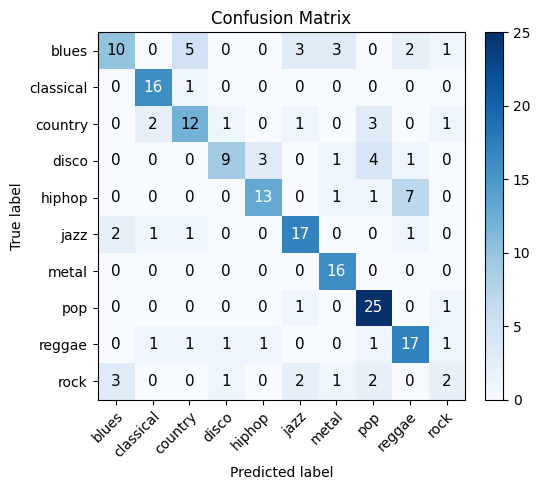

In [6]:
svmOvR.evaluate_accuracy(X_test, Y_test)
svmOvR.evaluate_models(X_test, Y_test)

true_labels = labels_encoding(Y_test, labels=class_names, pos_value=1, neg_value= 0)
pred_labels = labels_encoding(svmOvR(X_test), labels=class_names, pos_value=1, neg_value= 0)

confusion_matrix(true_labels, pred_labels, num_classes=10, class_names=class_names)

### OvO model

Then we train the OvO classification strategy with the RBF Binary Kernel SVM model.

Then evaluate the performance over the test data. Both single model as well as overall performance statistics are calculated.

In [7]:
svmOvO = KernelMulticlassOvO(kernel=config["kernel"], sigma=sigma, C=config["C"])
svmOvO.fit(X_train, Y_train)

🎯 Overall accuracy (OvO): 71.0000 %
📊 Accuracy of each OvO binary classifier:
  - Classifier 'blues' vs 'classical': 97.5610
  - Classifier 'blues' vs 'country': 81.8182
  - Classifier 'blues' vs 'disco': 100.0000
  - Classifier 'blues' vs 'hiphop': 97.8261
  - Classifier 'blues' vs 'jazz': 89.1304
  - Classifier 'blues' vs 'metal': 92.5000
  - Classifier 'blues' vs 'pop': 100.0000
  - Classifier 'blues' vs 'reggae': 91.4894
  - Classifier 'blues' vs 'rock': 85.7143
  - Classifier 'classical' vs 'country': 94.5946
  - Classifier 'classical' vs 'disco': 97.1429
  - Classifier 'classical' vs 'hiphop': 100.0000
  - Classifier 'classical' vs 'jazz': 89.7436
  - Classifier 'classical' vs 'metal': 100.0000
  - Classifier 'classical' vs 'pop': 100.0000
  - Classifier 'classical' vs 'reggae': 95.0000
  - Classifier 'classical' vs 'rock': 96.4286
  - Classifier 'country' vs 'disco': 84.2105
  - Classifier 'country' vs 'hiphop': 100.0000
  - Classifier 'country' vs 'jazz': 88.0952
  - Classifier

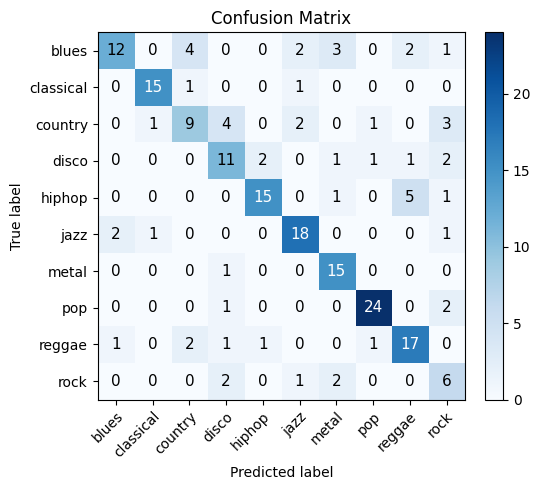

In [8]:
svmOvO.evaluate_accuracy(X_test, Y_test)
svmOvO.evaluate_models(X_test, Y_test)

true_labels = labels_encoding(Y_test, labels=class_names, pos_value=1, neg_value= 0)
pred_labels = labels_encoding(svmOvO(X_test), labels=class_names, pos_value=1, neg_value= 0)

confusion_matrix(true_labels, pred_labels, num_classes=10, class_names=class_names)

### MLP model

The first NN we train is a MLP model with the following configuration:
- input size 40, two hidden layers with widths 128 and 64, and output size 10
- Adam Optimizer
- ReLU as activation function
- Softmax as output activation
- Cross-Entropy as loss function

The labels are hot-encoded and the overall performance is calculated.

In [9]:
# Convert string labels to integer class labels
Y_train_int = labels_to_numbers(Y_train)
Y_test_int = labels_to_numbers(Y_test)

# Then apply one-hot encoding
Y_train_encoded = one_hot_encoding(Y_train_int)
Y_test_encoded = one_hot_encoding(Y_test_int)

In [10]:
model = MLP(
    widths=config["layer_widths"], 
    optimizer= AdamOptimizer(learning_rate= config["optimizer_learning_rate"]),
    activation=config["activation"],
    output_activation=config["output_activation"],
    loss=config["loss"]
)

In [11]:
metrics_dict = {
    "accuracy": accuracy,
    "loss" : cross_entropy,
}

metrics_history = model.fit(X_train, Y_train_encoded, num_epochs= config["epochs"], batch_size= config["batch_size"], compute_metrics=True, metrics_dict=metrics_dict)

In [12]:
print(f"Train accuracy: {metrics_history['accuracy'][-1]:.2f}% | "
      f"Test accuracy: {accuracy(model.decision_function(X_test), Y_test_encoded):.2f}%")

Train accuracy: 99.88% | Test accuracy: 74.50%


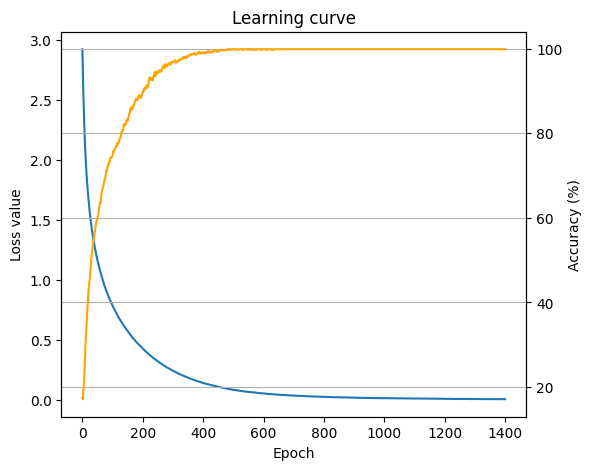

In [13]:
plot_learning_curves(metrics_history)

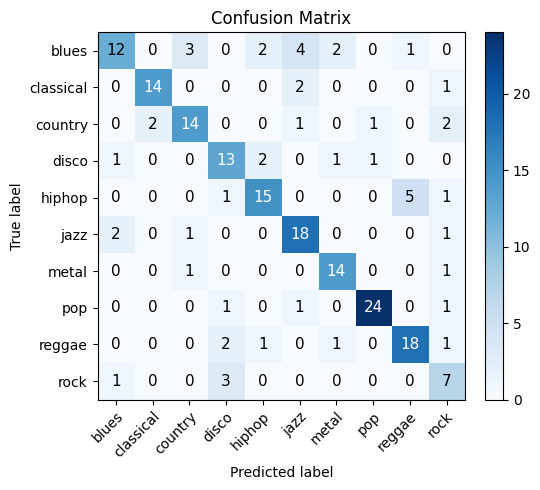

In [14]:
# Convert true string labels to integer class indices
Y_test_int = labels_to_numbers(Y_test, class_names=class_names)

# Get predicted class indices from model
Y_pred_int = model(X_test)  # it returns integers

# Convert both to one-hot encoded
num_classes = len(class_names)
true_labels_onehot = one_hot_encoding(Y_test_int, num_classes)
pred_labels_onehot = one_hot_encoding(Y_pred_int, num_classes)

# Plot confusion matrix 
confusion_matrix(
    y_true=true_labels_onehot,
    y_pred=pred_labels_onehot,
    num_classes=num_classes,
    plot=True,
    class_names=class_names
)


### CNN on spectograms using torch library

Spectograms provided in the GZTAN dataset

note: one jazz spectogram missing so there is 999 datapoints

In [2]:
# Load dataset from folders
dataset, tranformer_train = loaders.load_spectrograms(config_cnn)


### Train-test split

In [3]:
train_dataset, val_dataset = train_test_split_images(dataset, config_cnn["training_data_fraction"], transform_train=tranformer_train)

train_loader, val_loader = loaders.get_data_loaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    batch_size=config_cnn["batch_size"],
    shuffle=True)

# Show class names
print("Classes:", dataset.classes)
print("Number of training samples:", len(train_dataset))
print("Number of validation samples:", len(val_dataset))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Classes: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Number of training samples: 799
Number of validation samples: 200


### Train the model and save metrics

Training for 25 epochs should take 5-10 minutes, usually around 20s per epoch

In [17]:
model = SimpleCNN(config_cnn).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config_cnn["learning_rate"])

metrics_history = model.fit(train_loader, train_dataset, optimizer=optimizer, criterion=criterion, epochs=config_cnn["epochs"], device=device, val_loader=val_loader, val_dataset=val_dataset)


🎯 Overall accuracy: 13.50%
Epoch 1, Loss: 2.3220, Train Acc: 0.1227
🎯 Overall accuracy: 21.50%
Epoch 2, Loss: 2.1135, Train Acc: 0.1952
🎯 Overall accuracy: 26.00%
Epoch 3, Loss: 2.0151, Train Acc: 0.2753
🎯 Overall accuracy: 25.00%
Epoch 4, Loss: 2.0280, Train Acc: 0.2466
🎯 Overall accuracy: 31.00%
Epoch 5, Loss: 1.9055, Train Acc: 0.3054
🎯 Overall accuracy: 30.00%
Epoch 6, Loss: 1.8000, Train Acc: 0.3204
🎯 Overall accuracy: 33.50%
Epoch 7, Loss: 1.7457, Train Acc: 0.3692
🎯 Overall accuracy: 37.50%
Epoch 8, Loss: 1.6570, Train Acc: 0.4005
🎯 Overall accuracy: 39.50%
Epoch 9, Loss: 1.5972, Train Acc: 0.4118
🎯 Overall accuracy: 37.50%
Epoch 10, Loss: 1.5303, Train Acc: 0.4506
🎯 Overall accuracy: 44.00%
Epoch 11, Loss: 1.4571, Train Acc: 0.4706
🎯 Overall accuracy: 46.00%
Epoch 12, Loss: 1.4489, Train Acc: 0.4781
🎯 Overall accuracy: 45.50%
Epoch 13, Loss: 1.4411, Train Acc: 0.4693
🎯 Overall accuracy: 43.00%
Epoch 14, Loss: 1.4282, Train Acc: 0.4944
🎯 Overall accuracy: 48.50%
Epoch 15, Loss: 

🎯 Overall accuracy: 58.00%


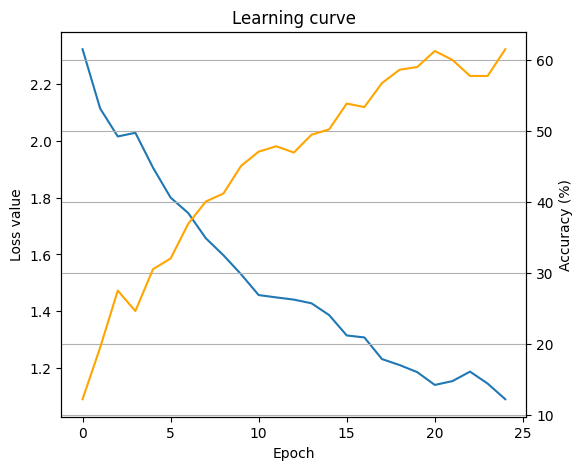

In [18]:
model.evaluate_accuracy(val_loader, val_dataset, device=device)

plot_learning_curves(metrics_history)

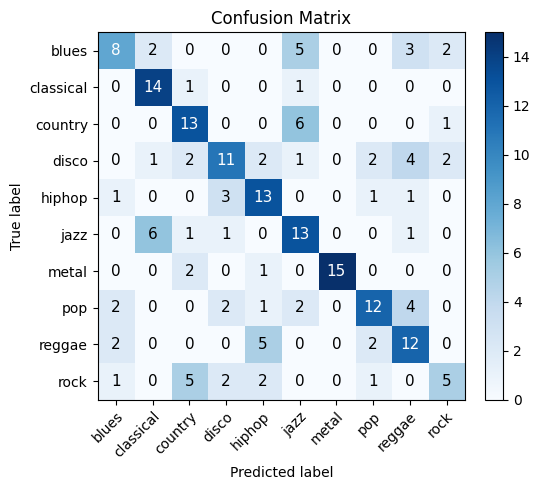

In [19]:
Y_true_int, Y_pred_int = model.get_true_and_pred_labels(val_loader, device=device)

# Convert to one-hot encoded
num_classes = config_cnn["num_classes"]  
true_labels_onehot = one_hot_encoding(Y_true_int, num_classes)
pred_labels_onehot = one_hot_encoding(Y_pred_int, num_classes)

# Plot confusion matrix
confusion_matrix(
    y_true=true_labels_onehot,
    y_pred=pred_labels_onehot,
    num_classes=num_classes,
    plot=True,
    class_names=dataset.classes  # or class_names if you've defined it elsewhere
)

### Optional: save the model

In [20]:
#path = "pretrained_models/cnn_trained_100epochs"

#model.save_model(metrics_history, path, config=config_cnn)

### Load pretrained model for 100 epochs

🎯 Overall accuracy: 59.00%


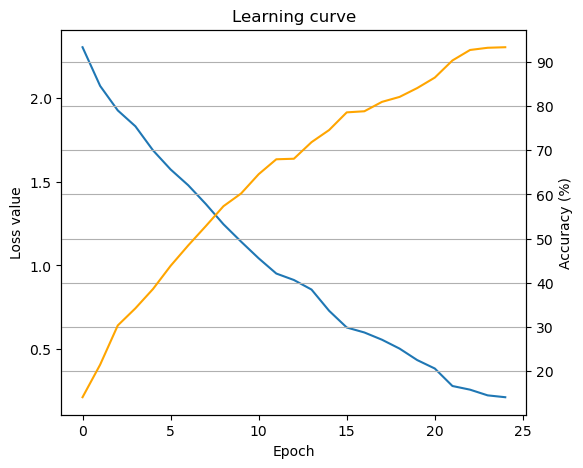

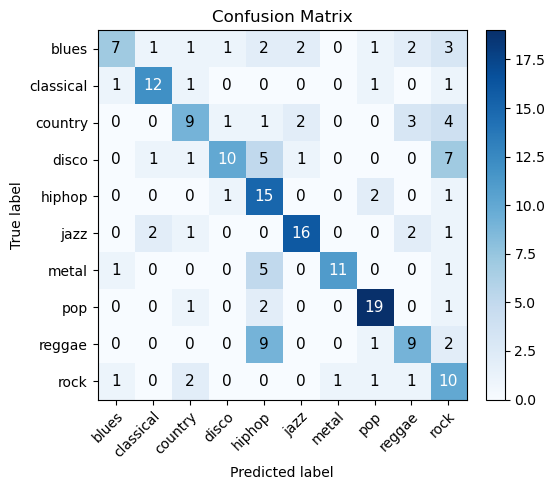

In [6]:
# Load the pretrained model for 100 epochs
path = "pretrained_models/cnn_trained_25epochs"

model100, metrics_history100 = load_SimpleCNN_model(path, device=device)

model100.evaluate_accuracy(val_loader, val_dataset, device=device)

plot_learning_curves(metrics_history100)

# Collect predictions and true labels on validation set
Y_true_int, Y_pred_int = model100.get_true_and_pred_labels(val_loader, device=device)

# Convert to one-hot encoded
num_classes = config_cnn["num_classes"]  
true_labels_onehot = one_hot_encoding(Y_true_int, num_classes)
pred_labels_onehot = one_hot_encoding(Y_pred_int, num_classes)

# Plot confusion matrix
confusion_matrix(
    y_true=true_labels_onehot,
    y_pred=pred_labels_onehot,
    num_classes=num_classes,
    plot=True,
    class_names=dataset.classes  # or class_names if you've defined it elsewhere
)